In [19]:
import numpy as np
sentences = [
    "I love AI",
    "Deep Learning is amazing",
    "I love Python"
]

In [20]:
y = np.array([1, 1, 0])

In [21]:
print(type(X))
print(type(y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


# Tokenization

In [2]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)
sequences = tokenizer.texts_to_sequences(sentences)

print(sequences)

[[1, 2, 3], [4, 5, 6, 7], [1, 2, 8]]


# Pad Sequences

In [4]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X = pad_sequences(
    sequences,
    maxlen=5,
    padding="post"
)

print(X)

[[1 2 3 0 0]
 [4 5 6 7 0]
 [1 2 8 0 0]]


# Build RNN Model

In [6]:
import warnings
warnings.filterwarnings('ignore')

In [7]:
import tensorflow as tf

model = tf.keras.Sequential([

    tf.keras.layers.Embedding(
        input_dim=1000,
        output_dim=64,
        input_length=5
    ),

    tf.keras.layers.SimpleRNN(
        units=64
    ),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )

])

# Compile

In [8]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

# Train the Model

In [24]:
history = model.fit(
    X,
    y,
    epochs=10,
    batch_size=2
)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.0758
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0581
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.0461
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0361
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.0276
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0204
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0163
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0132
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0110
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0092


# Evaluate the Model

In [25]:
loss, accuracy = model.evaluate(X, y)

print("Loss:", loss)
print("Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 1.0000 - loss: 0.0081
Loss: 0.008070968091487885
Accuracy: 1.0


# Make Predictions

In [26]:
test = ["I love Python"]

In [27]:
test_seq = tokenizer.texts_to_sequences(test)

In [28]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

test_pad = pad_sequences(
    test_seq,
    maxlen=5,
    padding="post"
)

In [29]:
prediction = model.predict(test_pad)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
[[0.00934305]]


In [30]:
if prediction[0][0] > 0.5:
    print("Positive")
else:
    print("Negative")

Negative


# Plot Training History

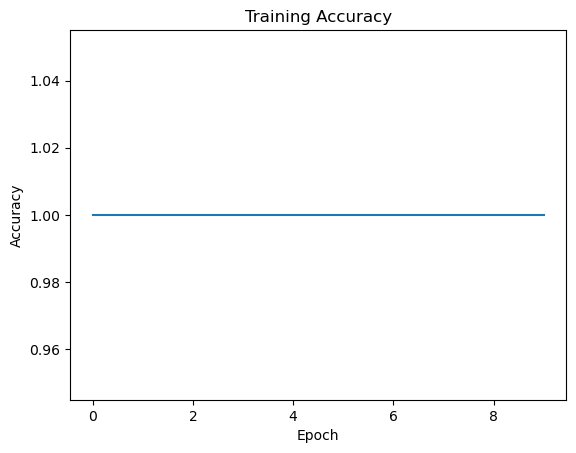

In [31]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"])
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

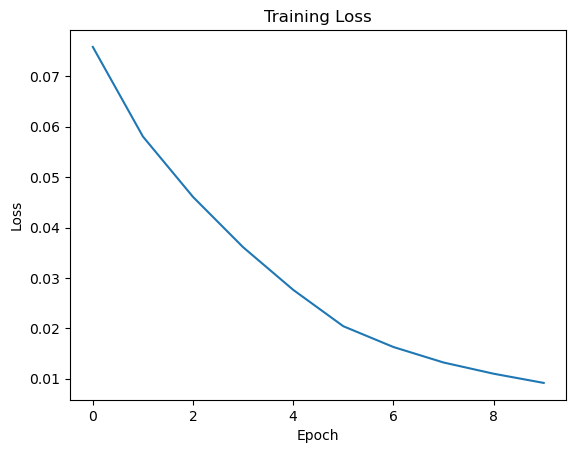

In [32]:
plt.plot(history.history["loss"])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()